# **I. Classification**
* **Definition:** A supervised machine learning method that uses trained models to predict discrete, categorical labels for new data.
* **Mechanism:** It maps the association between input features and target variables to classify data into predefined categories. 

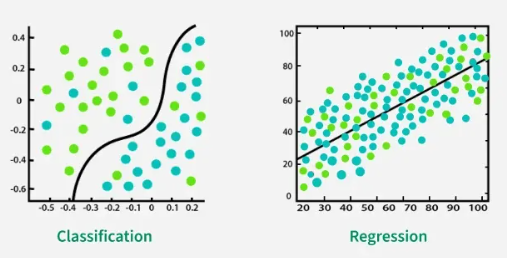

## **1/ Real-World Applications**
* **Business & Marketing:** 
  * **Churn Prediction:** Identifying if a customer is likely to discontinue a service.
  * **Customer Segmentation:** Categorizing customers into specific demographic or behavioral groups.
  * **Ad Responsiveness:** Predicting whether a customer will engage with an advertising campaign.
* **Finance:** Predicting loan defaults (binary classification: default vs. no default) based on applicant age, income, and debt levels.
* **Healthcare:** Recommending specific drug prescriptions (multi-class classification) based on how similar patients responded to treatments.
* **Technology:** Email filtering (spam vs. inbox), speech-to-text, handwriting recognition, and biometric identification.

## **2/ Common Classification Algorithms**
* Naive Bayes
* Logistic Regression
* Decision Trees
* K-Nearest Neighbors (KNN)
* Support Vector Machines (SVM)
* Neural Networks

*(Note: Algorithms like Logistic Regression, KNN, and Decision Trees can natively distinguish multiple classes. Others are strictly binary and require extension strategies to handle multi-class problems.)*

## **3/ Multi-Class Classification Strategies**
Techniques used to extend strictly binary classifiers to handle datasets with more than two target classes.

* **One-Versus-All (OvA) / One-Versus-Rest:**
  * Implements exactly $k$ independent binary classifiers for a dataset with $k$ classes.
  * Each classifier makes a binary prediction for a single label: *"Does it belong to Class A, or everything else?"*
  * **Outlier Detection:** Data points that fail to trigger any of the individual classifiers fall into an "unclassified" bucket, which is highly useful for identifying noise or anomalies.
* **One-Versus-One (OvO):**
  * Evaluates every possible pair of classes.
  * Each classifier focuses strictly on two labels at a time, asking: *"Is it Class A or Class B?"*
  * **Voting Scheme:** The final class prediction is determined by popularity (the class that wins the most binary match-ups). In the event of a tie, the scheme can be improved by weighing votes based on the confidence level/probability of each classifier's prediction.

---

# **II. Decision Trees Overview**
* **Definition:** A supervised machine learning algorithm visualized as a flowchart for classifying data points.
  * **Internal Node:** Represents a test on a specific feature (e.g., "Is cholesterol high?").
  * **Branch:** Represents the outcome or result of the test.
  * **Leaf / Terminal Node:** Assigns the final class label (e.g., "Prescribe Drug A").
* **Key Advantages:** They are highly interpretable (easy to visualize) and automatically reveal feature importance (the most predictive features appear at the top of the tree).


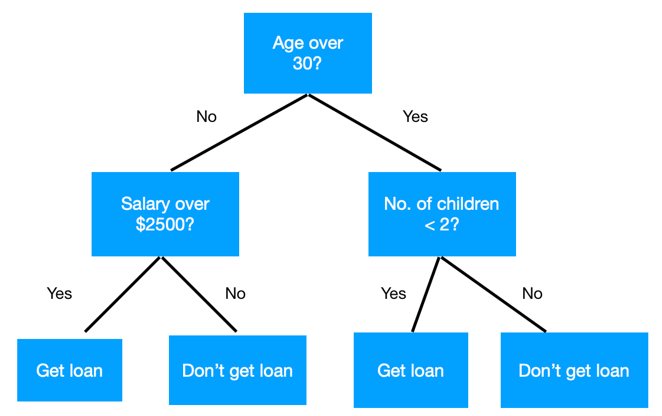

## **1/ Training & Splitting the Data**
* **Recursive Partitioning:** The tree is built by evaluating features one by one, selecting the feature that *best* separates the data into its predefined classes at each node.
* **Splitting Criteria (Measuring Split Quality):**
  * **Entropy:** Measures the disorder, randomness, or uncertainty in a node.
    * `0` = Completely homogenous (pure node, all data belongs to one class).
    * `1` = Completely random (classes are equally divided).
    * *Goal:* The algorithm seeks splits that result in the lowest possible entropy.
  * **Information Gain (Entropy Reduction):** Calculated as the entropy of the tree *before* the split minus the weighted entropy *after* the split. The algorithm prioritizes features that return the highest Information Gain.
  * **Gini Impurity:** Another common metric used alongside Information Gain to evaluate split quality.

## **2/ Pruning & Stopping Criteria**
* **The Overfitting Problem:** If a tree is allowed to grow until every leaf is perfectly pure, it will memorize the training data—including noise and irrelevant details—resulting in a highly complex model that performs poorly on new data.
* **Pruning:** The process of cutting branches that don't significantly improve performance. It simplifies the model, improves generalization, and increases predictive accuracy.
* **Stopping Criteria (Pre-emptive Pruning):** You can force the tree to stop growing when certain thresholds are met:
  * The maximum tree depth is reached.
  * A node contains fewer than the minimum required data points to split.
  * A leaf contains fewer than the minimum required samples.
  * The maximum allowed number of leaf nodes is reached.


# **III. Regression Trees vs. Classification Trees**
* **Definition:** A regression tree is analogous to a decision tree but is designed to predict **continuous values** (e.g., salary, temperature, revenue) rather than discrete categorical labels.
* **Leaf Node Predictions:** 
  * *Classification:* Uses a majority vote to assign a discrete class.
  * *Regression:* Uses the **average (mean)** of the target values in that node to make a prediction (or the median if the data is highly skewed).

## **1/Building a Regression Tree**
* **The Splitting Goal:** Unlike classification trees that use Entropy or Information Gain, regression trees recursively split the dataset to **minimize the variance or Mean Squared Error (MSE)** of the target values. This process reduces the spread of the predicted values within each node.
* **Measuring Split Quality:** 
  * The model calculates the MSE for the left and right subsets of a potential split. 
  * It then calculates the **weighted average of the MSEs** for those splits. 
  * The split with the lowest weighted MSE (lowest variance) is chosen as the optimal split.

## **2/Handling Different Feature Types**
* **Binary Features:** The data is separated into its two natural categories, and the split quality is evaluated using the weighted average of their MSEs.
* **Categorical Features with Multiple Levels:** The model evaluates different **binary partitions** of the categories and selects the partition that minimizes the weighted MSE *(Note: Do not use classification strategies like One-Versus-All here)*.
* **Continuous Features:** 
  1. Sort the feature's values and drop duplicates.
  2. Define candidate thresholds ($\alpha_i$) as the midpoints between each pair of consecutive values: $\alpha_i = \frac{X_i + X_{i+1}}{2}$.
  3. Exhaustively test these thresholds to find the one that minimizes the weighted MSE. 
  4. *Optimization:* For massive datasets, sampling a sparse subset of these thresholds based on the data's distribution can improve computational efficiency.

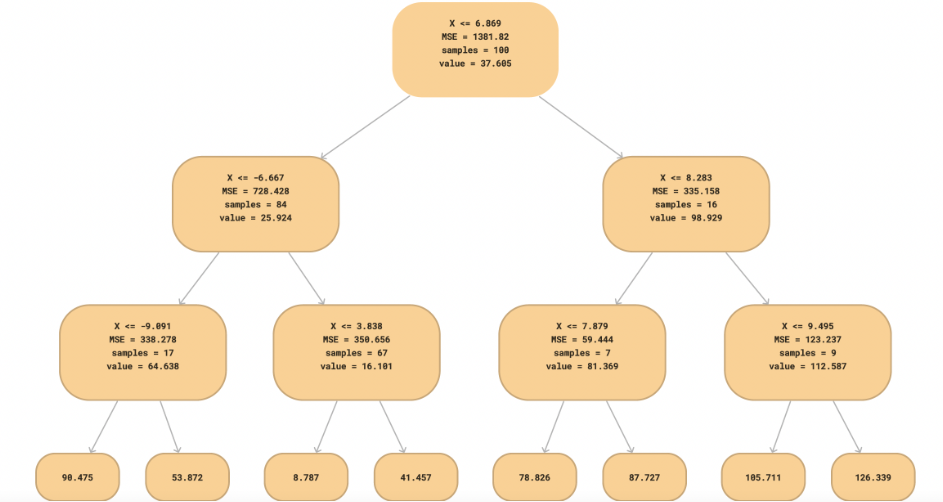